In [31]:
# Importacion de las librerias
from collections import Counter
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [32]:
# Lectura del archivo
df = pd.read_csv('techmindv1.csv', engine='python')


In [33]:
display(df)

,titulo,texto,categoria,fuente,tags,calidad
0,How do you get state in a custom Extractor?,I'm trying to use Axum's custom extractor to i...,Seguridad,stackoverflow,"rust, jwt, rust-axum",1.0
1,FROM WEB DEVELOPMENT TO BI- EP01,From Web Development To Business intelligence\...,Backend,medium,"['Obiee', 'Odi', 'Oracle', 'Java', 'Jee']",NaN
2,pybind11: how to add document the exported mod...,"I have some c++ code, and I successfully expor...",Programación General,stackoverflow,"python, c++, pybind11",0.9
3,Reference elements in matrices in Julia while ...,I have a vector X whose elements are zeros and...,Ciencia de Datos,stackoverflow,"matlab, julia",1.0
4,"The Falcor data model is a graph, and the Grap...",Falcor\n\nOut of the two Falcor was my first l...,Frontend,medium,"['API', 'JavaScript', 'Nodejs', 'React', 'Soft...",NaN
...,...,...,...,...,...,...
36709,Cannot submit login form with Selenium (Python...,I am trying to login to a website using Seleni...,Frontend,stackoverflow,"python, html, selenium-webdriver",1.0
36710,Room with KMM: Unresolved reference 'instantia...,I'm trying to implement Room into my Kotlin Mu...,Mobile,stackoverflow,"android, ios, kotlin, gradle, kotlin-multiplat...",0.9
36711,Things to know — Amazon Aurora DB,Features that are worth exploring\n\nParallel ...,DevOps / Cloud,medium,"['Relational Databases', 'Getting Started', 'T...",NaN
36712,Create Polars DataFrame with Flattened Json File,The problem that I have is trying to read in a...,Programación General,stackoverflow,"rust, rust-polars",1.0


In [34]:
#Observamos las dimenciones del data set
df.shape

(36714, 6)

In [35]:
# Tenemos que observar la infromacion del data set
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36714 entries, 0 to 36713
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   titulo     36714 non-null  object 
 1   texto      36714 non-null  object 
 2   categoria  36714 non-null  object 
 3   fuente     36714 non-null  object 
 4   tags       36714 non-null  object 
 5   calidad    25574 non-null  float64
dtypes: float64(1), object(5)
memory usage: 1.7+ MB


In [36]:
#definimos la suma de los valores null por columna
nulos = df.isnull().sum()
print(nulos)

titulo           0
texto            0
categoria        0
fuente           0
tags             0
calidad      11140
dtype: int64


In [37]:
#comprobamos si algun dato esta duplicado en alguna fila
duplicados_totales = df.duplicated().sum()
print(f'Número de filas duplicadas: {duplicados_totales}')

Número de filas duplicadas: 0


In [38]:
# Buscamos los duplicados por columna especifica
duplicados_titulo = df.duplicated(subset=['titulo']).sum()
print(f'Títulos repetidos: {duplicados_titulo}')

Títulos repetidos: 0


In [39]:
duplicados_texto = df.duplicated(subset=['texto']).sum()
print(f'Textos repetidos: {duplicados_texto}')

Textos repetidos: 0


In [40]:
# En este caso de la columna no importa los duplicados por los temas que se manejaron en el data set
duplicados_categoria = df.duplicated(subset=['categoria']).sum()
print(f'Títulos repetidos: {duplicados_categoria}')

Títulos repetidos: 36706


In [41]:
# No hacemos nada por repetidos ya que las fuentes pueden ser las mismas para los temas
duplicados_fuente = df.duplicated(subset=['fuente']).sum()
print(f'Títulos repetidos: {duplicados_fuente}')

Títulos repetidos: 36712


In [42]:
duplicados_tags = df.duplicated(subset=['tags']).sum()
print(f'Títulos repetidos: {duplicados_tags}')

Títulos repetidos: 6207


In [43]:
duplicados_calidad = df.duplicated(subset=['calidad']).sum()
print(f'Títulos repetidos: {duplicados_calidad}')

Títulos repetidos: 36389


In [48]:
# Conteo por categoria dividida por categoria
conteo_cat = df['categoria'].value_counts()

In [49]:
display(conteo_cat)

,count
categoria,
Backend,5000
Programación General,5000
Ciencia de Datos,5000
Frontend,5000
Mobile,5000
DevOps / Cloud,5000
Bases de Datos,4140
Seguridad,2574


In [50]:
#Analisis de longitud del promedio
df['long_titulo'] = df['titulo'].astype(str).apply(lambda x: len(x.split()))
df['long_texto'] = df['texto'].astype(str).apply(lambda x: len(x.split()))
display(df[['long_titulo', 'long_texto']].describe())

,long_titulo,long_texto
count,36714.000000,36714.000000
mean,9.662990,351.494035
std,4.091333,510.865793
min,1.000000,15.000000
25%,7.000000,82.000000
50%,9.000000,139.000000
75%,12.000000,348.750000
max,41.000000,3740.000000


/tmp/ipykernel_4711/1049983864.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


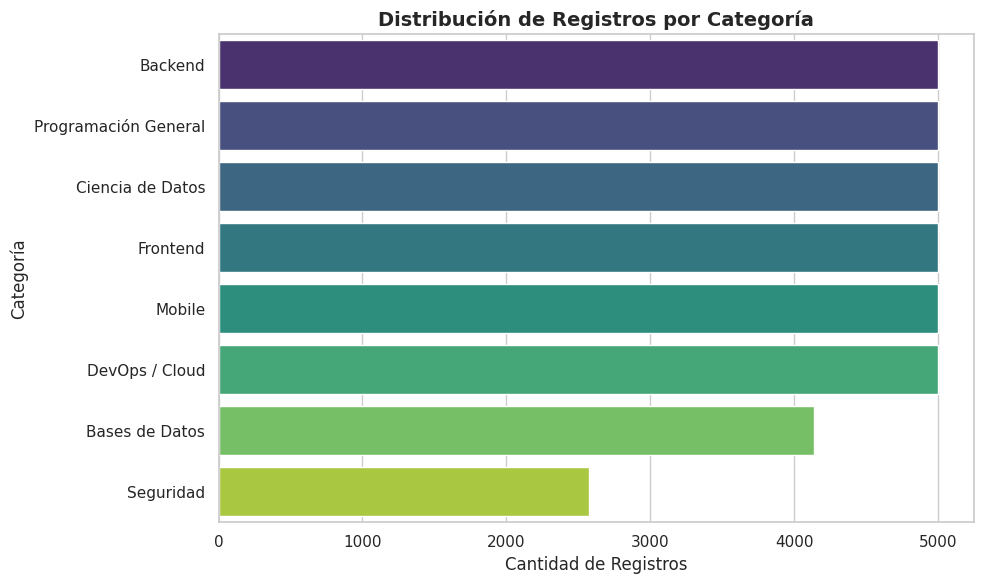

In [52]:
sns.set_theme(style='whitegrid')

# --- GRÁFICO 1: Distribución de Categorías ---
plt.figure(figsize=(10, 6))
sns.countplot(
    data=df,
    y='categoria',
    order=df['categoria'].value_counts().index,
    palette='viridis',
)
plt.title('Distribución de Registros por Categoría', fontsize=14, fontweight='bold')
plt.xlabel('Cantidad de Registros', fontsize=12)
plt.ylabel('Categoría', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_categorias.png', dpi=300)  # Guarda la imagen en alta calidad
plt.show()

/tmp/ipykernel_4711/2668435801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


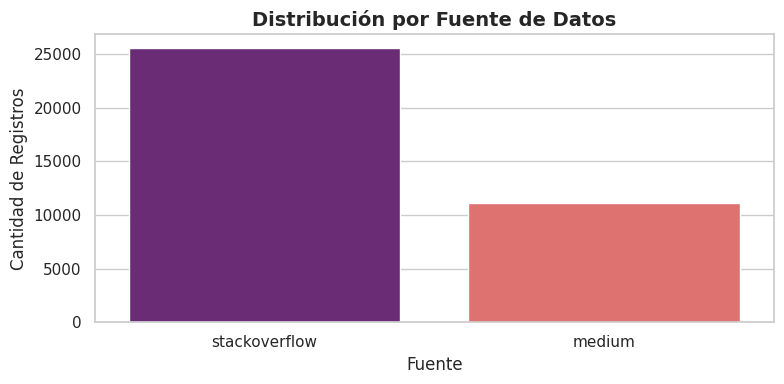

In [53]:
# --- GRÁFICO 2: Distribución por Fuente ---
plt.figure(figsize=(8, 4))
sns.countplot(
    data=df,
    x='fuente',
    order=df['fuente'].value_counts().index,
    palette='magma',
)
plt.title('Distribución por Fuente de Datos', fontsize=14, fontweight='bold')
plt.xlabel('Fuente', fontsize=12)
plt.ylabel('Cantidad de Registros', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_fuentes.png', dpi=300)
plt.show()

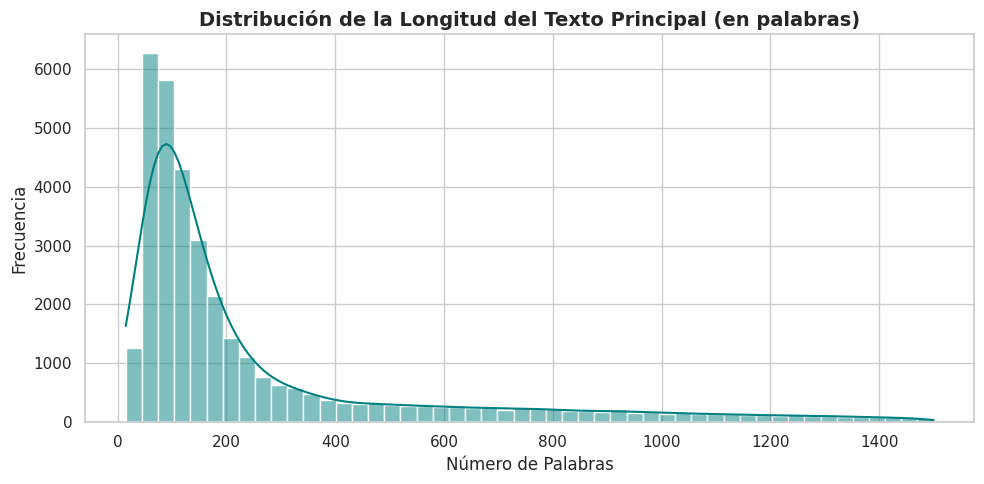

In [54]:
plt.figure(figsize=(10, 5))
# Limitamos a un rango razonable (ej. hasta 1500 palabras) para que el histograma se vea limpio y no lo aplasten los outliers
textos_filtrados = df['long_texto'][df['long_texto'] <= 1500]
sns.histplot(textos_filtrados, bins=50, kde=True, color='teal')
plt.title(
    'Distribución de la Longitud del Texto Principal (en palabras)',
    fontsize=14,
    fontweight='bold',
)
plt.xlabel('Número de Palabras', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_longitud_texto.png', dpi=300)
plt.show()

RECUENCIA DE PALABRAS

In [55]:
# Unir todos los títulos y textos en un solo gran texto en minúsculas
texto = (
    ' '.join(df['titulo'].astype(str)) + ' ' + ' '.join(df['texto'].astype(str))
)
palabras = re.findall(r'\b\w+\b', texto.lower())

In [56]:
# Filtrar palabras muy cortas (menores a 4 letras) para descartar artículos o preposiciones comunes
palabras_filtradas = [p for p in palabras if len(p) > 3]

In [59]:
#Contar las 20 palabras más frecuentes
contador = Counter(palabras_filtradas)
palabras_frecuentes = pd.DataFrame(
    contador.most_common(20), columns=['Palabra', 'Frecuencia']
)

In [60]:
display(palabras_frecuentes)

,Palabra,Frecuencia
0,that,141112
1,this,130722
2,with,106495
3,have,69706
4,from,59636
5,data,56227
6,will,52385
7,your,51549
8,using,43170
9,code,41528


/tmp/ipykernel_4711/790389919.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=palabras_frecuentes, x='Frecuencia', y='Palabra', palette='crest')


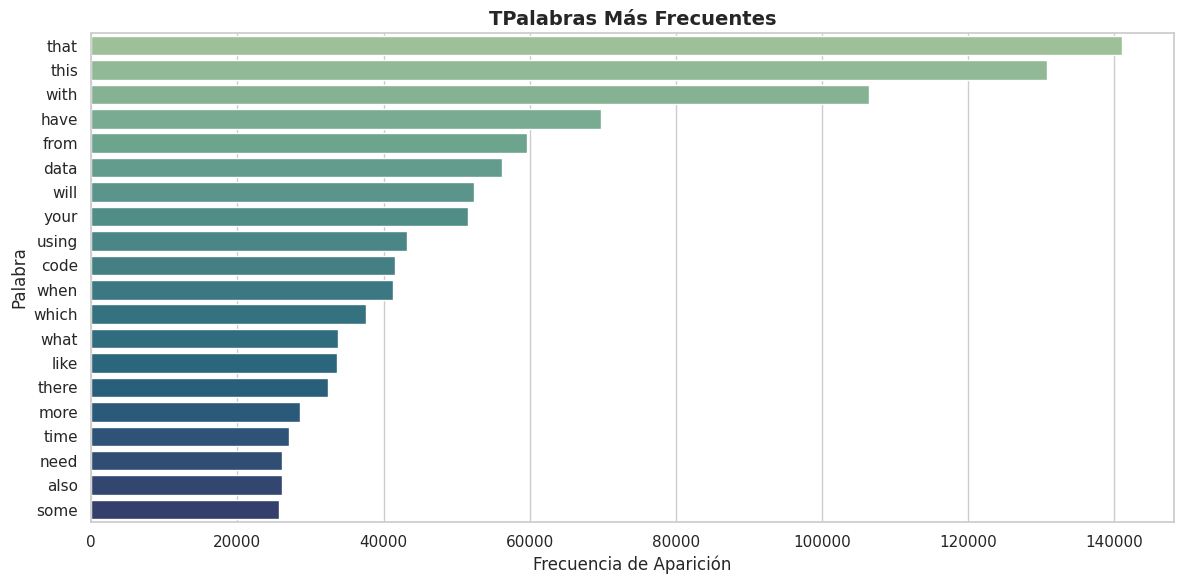

In [61]:
plt.figure(figsize=(12, 6))
sns.barplot(data=palabras_frecuentes, x='Frecuencia', y='Palabra', palette='crest')
plt.title(
    'TPalabras Más Frecuentes', fontsize=14, fontweight='bold'
)
plt.xlabel('Frecuencia de Aparición', fontsize=12)
plt.ylabel('Palabra', fontsize=12)
plt.tight_layout()
plt.savefig('grafico_de_palabras.png', dpi=300)
plt.show()